In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np

In [4]:
train_data = pd.read_csv('regression/steps-large-training.csv', index_col=0)
test_data = pd.read_csv('regression/steps-large-test.csv', index_col=0)
print(train_data.shape)
train_data.head()


(10000, 2)


,x,y
1,-1.481354,-80
2,1.033264,80
3,-0.076403,0
4,-1.419785,-80
5,-0.108398,0


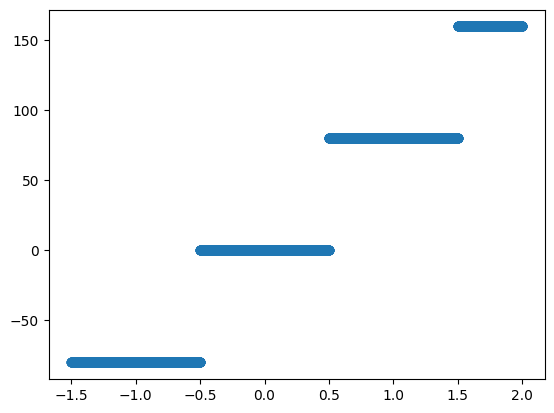

In [5]:
import matplotlib.pyplot as plt
plt.scatter(train_data['x'], train_data['y'])

In [6]:
mi = train_data.mean()
std = train_data.std()
train_data = (train_data - mi) / std
test_data = (test_data - mi) / std

In [7]:
X_train = torch.tensor(train_data['x'].values, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(train_data['y'].values, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(test_data['x'].values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_data['y'].values, dtype=torch.float32).unsqueeze(1)

In [8]:
from sklearn.metrics import mean_squared_error
def model_train(hidden_size = 5, no_of_layers = 1,iters = 100, learning_rate = 0.001):
    model = nn.Sequential(nn.Linear(1, hidden_size))
    for i in range(no_of_layers):
        model.append(nn.Sigmoid())
        if i == no_of_layers - 1:
            model.append(nn.Linear(hidden_size, 1))
        else:
            model.append(nn.Linear(hidden_size, hidden_size))
    loss = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    device = 'cpu'
    model.to(device)
    for epoch in range(iters):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        lo = loss(y_pred, y_train)
        lo.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test.unsqueeze(1))
    mse_y = y_pred_test.numpy().flatten() * std['y'] + mi['y']
    mse_y_pred = y_test.numpy().flatten() * std['y'] + mi['y']
    mse = mean_squared_error(mse_y, mse_y_pred)
    print(f"MSE: {mse}, learning rate: {learning_rate}")
    return mse, model, y_pred_test.numpy().flatten()

In [9]:
models = []
for i in np.linspace(0.001, 1, 20):
    mse, model,y_pred51 = model_train(hidden_size=5, no_of_layers=1, iters=1000, learning_rate=i)
    models.append((mse, model, y_pred51))
idx = np.argmin([m[0] for m in models])
best_model_5_1 = models[idx][1]
y_pred51 = models[idx][2]

MSE: 526.5654213782514, learning rate: 0.001
MSE: 447.6702725704184, learning rate: 0.05357894736842105
MSE: 396.3882035171755, learning rate: 0.1061578947368421
MSE: 301.58630243051545, learning rate: 0.15873684210526315
MSE: 146.35703412639901, learning rate: 0.2113157894736842
MSE: 127.58735048680269, learning rate: 0.26389473684210524
MSE: 119.02876711202505, learning rate: 0.3164736842105263
MSE: 175.56788514335483, learning rate: 0.36905263157894735
MSE: 168.92394466557278, learning rate: 0.4216315789473684
MSE: 366.0545150932981, learning rate: 0.47421052631578947
MSE: 442.22763571107066, learning rate: 0.5267894736842105
MSE: 107.32449458461144, learning rate: 0.5793684210526315
MSE: 104.43690661803613, learning rate: 0.6319473684210526
MSE: 342.5744770174916, learning rate: 0.6845263157894736
MSE: 328.4721766223913, learning rate: 0.7371052631578947
MSE: 122.53046409585373, learning rate: 0.7896842105263158
MSE: 118.46664261585035, learning rate: 0.8422631578947368
MSE: 507.11

In [10]:
for i in np.linspace(0.001, 1, 20):
    mse, model,y_pred101 = model_train(hidden_size=10, no_of_layers=1, iters=1000, learning_rate=i)
    models.append((mse, model, y_pred101))
idx = np.argmin([m[0] for m in models])
best_model_10_1 = models[idx][1]
y_pred101 = models[idx][2]

MSE: 514.0795330493904, learning rate: 0.001
MSE: 407.3677917050818, learning rate: 0.05357894736842105
MSE: 146.3631824970654, learning rate: 0.1061578947368421
MSE: 159.87756993250002, learning rate: 0.15873684210526315
MSE: 126.48441392337023, learning rate: 0.2113157894736842
MSE: 114.88076257970235, learning rate: 0.26389473684210524
MSE: 127.26664971920441, learning rate: 0.3164736842105263
MSE: 102.48719573669361, learning rate: 0.36905263157894735
MSE: 109.35841966328911, learning rate: 0.4216315789473684
MSE: 123.42727894899988, learning rate: 0.47421052631578947
MSE: 115.82644279061918, learning rate: 0.5267894736842105
MSE: 117.43701559614894, learning rate: 0.5793684210526315
MSE: 388.30885561949447, learning rate: 0.6319473684210526
MSE: 118.0065403099188, learning rate: 0.6845263157894736
MSE: 92.10732389542025, learning rate: 0.7371052631578947
MSE: 114.65680844072347, learning rate: 0.7896842105263158
MSE: 129.6030254248535, learning rate: 0.8422631578947368
MSE: 98.989

In [11]:
models = []
for i in np.linspace(0.0001, 0.1, 20):
    mse, model, y_pred52 = model_train(hidden_size=5, no_of_layers=2, iters=1000, learning_rate=i)
    models.append((mse, model, y_pred52))
idx = np.argmin([m[0] for m in models])
best_model_5_2 = models[idx][1]
y_pred52 = models[idx][2]

MSE: 6485.4240905874185, learning rate: 0.0001
MSE: 474.57661211208347, learning rate: 0.005357894736842106
MSE: 456.86146764620594, learning rate: 0.01061578947368421
MSE: 442.06359687807935, learning rate: 0.015873684210526314
MSE: 431.70714449905074, learning rate: 0.02113157894736842
MSE: 441.19660462759595, learning rate: 0.02638947368421053
MSE: 237.3261951315282, learning rate: 0.03164736842105263
MSE: 343.70607243462223, learning rate: 0.03690526315789474
MSE: 399.0925227141747, learning rate: 0.04216315789473685
MSE: 248.18336272770642, learning rate: 0.047421052631578954
MSE: 211.3193137797541, learning rate: 0.05267894736842106
MSE: 219.18805694054575, learning rate: 0.05793684210526316
MSE: 112.26948460692438, learning rate: 0.06319473684210526
MSE: 57.20357453971976, learning rate: 0.06845263157894738
MSE: 170.06212668943277, learning rate: 0.07371052631578948
MSE: 201.59478024288566, learning rate: 0.07896842105263159
MSE: 81.61143950784673, learning rate: 0.0842263157894

In [25]:
models = []
for i in np.linspace(0.0001, 0.1, 20):
    mse, model, y_pred52 = model_train(hidden_size=5, no_of_layers=2, iters=1000, learning_rate=i)
    models.append((mse, model, y_pred52))
idx = np.argmin([m[0] for m in models])
best_model_5_2 = models[idx][1]
y_pred52 = models[idx][2]

MSE: 6707.704324073437, learning rate: 0.0001
MSE: 477.2825179240224, learning rate: 0.005357894736842106
MSE: 465.6332698774136, learning rate: 0.01061578947368421
MSE: 449.45489655089284, learning rate: 0.015873684210526314
MSE: 436.4207569993117, learning rate: 0.02113157894736842
MSE: 297.20237344470337, learning rate: 0.02638947368421053
MSE: 429.18898530488366, learning rate: 0.03164736842105263
MSE: 183.923470447895, learning rate: 0.03690526315789474
MSE: 281.0079089346906, learning rate: 0.04216315789473685
MSE: 384.23097170483237, learning rate: 0.047421052631578954
MSE: 360.62525437660565, learning rate: 0.05267894736842106
MSE: 84.51606430014179, learning rate: 0.05793684210526316
MSE: 115.87349478323637, learning rate: 0.06319473684210526
MSE: 102.8260018304366, learning rate: 0.06845263157894738
MSE: 178.95613104689343, learning rate: 0.07371052631578948
MSE: 75.74090789034165, learning rate: 0.07896842105263159
MSE: 255.54611047198298, learning rate: 0.08422631578947369


In [26]:
_, best_model_44, y_pred44 = model_train(hidden_size=4, no_of_layers=4, iters=10000, learning_rate=0.05)


MSE: 2.3016163334009536, learning rate: 0.05


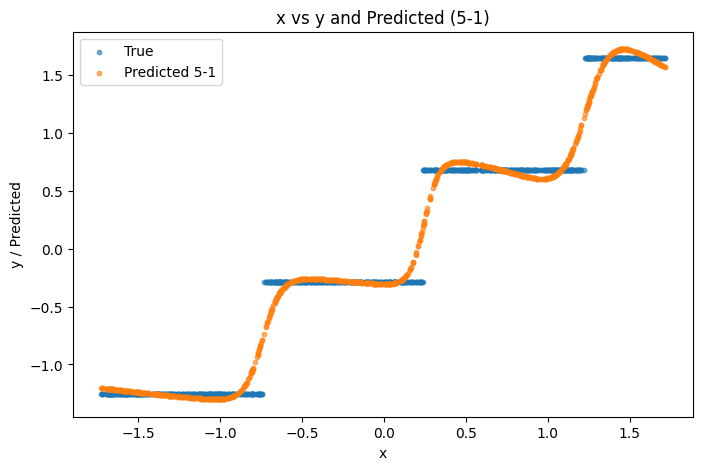

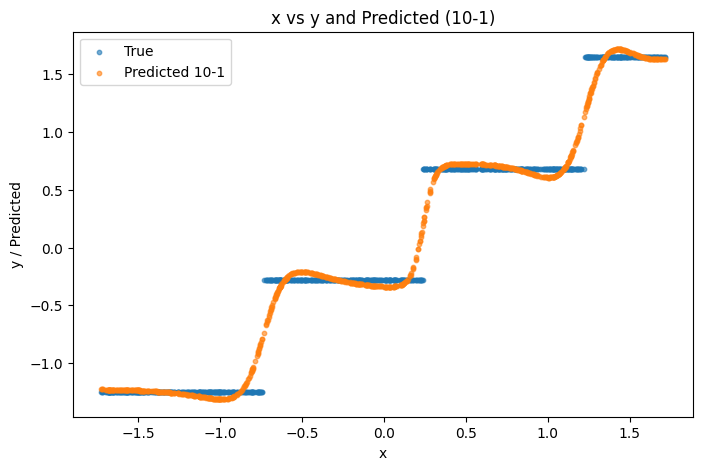

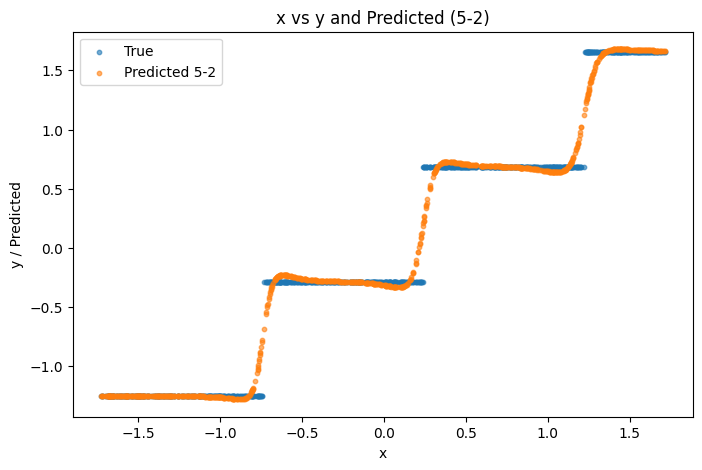

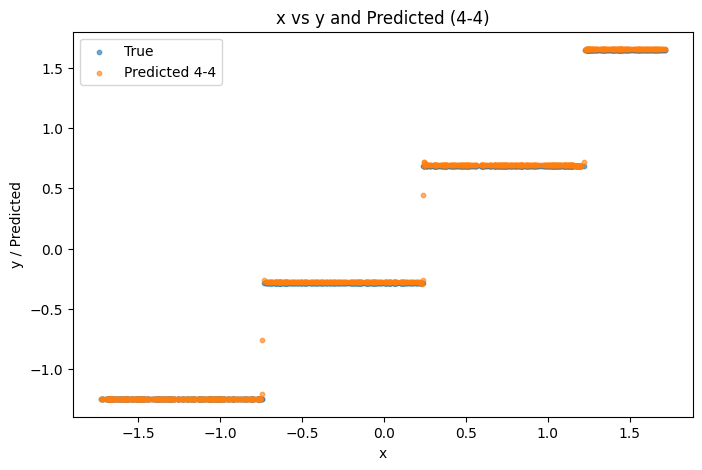

In [28]:
#wykresy wygenerowane z llm
plt.figure(figsize=(8, 5))
plt.scatter(test_data['x'], test_data['y'], s=10, alpha=0.6, label='True')
plt.scatter(test_data['x'], y_pred51, s=10, alpha=0.6, label='Predicted 5-1')
plt.xlabel('x')
plt.ylabel('y / Predicted')
plt.title('x vs y and Predicted (5-1)')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(test_data['x'], test_data['y'], s=10, alpha=0.6, label='True')
plt.scatter(test_data['x'], y_pred101, s=10, alpha=0.6, label='Predicted 10-1')
plt.xlabel('x')
plt.ylabel('y / Predicted')
plt.title('x vs y and Predicted (10-1)')
plt.legend()
plt.show()

# Plot: x vs y and x vs prediction for 5-2 model
plt.figure(figsize=(8, 5))
plt.scatter(test_data['x'], test_data['y'], s=10, alpha=0.6, label='True')
plt.scatter(test_data['x'], y_pred52, s=10, alpha=0.6, label='Predicted 5-2')
plt.xlabel('x')
plt.ylabel('y / Predicted')
plt.title('x vs y and Predicted (5-2)')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(test_data['x'], test_data['y'], s=10, alpha=0.6, label='True')
plt.scatter(test_data['x'], y_pred44, s=10, alpha=0.6, label='Predicted 4-4')
plt.xlabel('x')
plt.ylabel('y / Predicted')
plt.title('x vs y and Predicted (4-4)')
plt.legend()
plt.show()

In [14]:
from math import exp

class Value:
    def __init__(self, val, child=()):

        self.val = val
        self.grad = 0
        self.child = child
        self.back = lambda: None
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.val + other.val, (self, other))
        def back():
            self.grad += out.grad
            other.grad += out.grad
        out.back = back
        return out
    def __radd__(self, other):
        return self + other
    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        return self + (-other)
    def __rsub__(self, other):
        return other + (-self)
    def __pow__(self, other):
        assert isinstance(other, (int, float)), f"potega musi byc float albo int a teraz jest: {type(other)}"
        out = Value(self.val**other, (self,))
        def back():
            self.grad += (other * self.val**(other-1)) * out.grad
        out.back = back
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.val * other.val, (self, other))
        def back():
            self.grad += other.val * out.grad
            other.grad += self.val * out.grad
        out.back = back
        return out
    def __rmul__(self, other):
        return self * other
    def __truediv__(self, other):
        return self * (other**(-1))
    def __rtruediv__(self, other):
        return other * (self**(-1))

    def sigmoid(self):
        x = self.val
        if x < -500: # obcinanie f. żeby uniknąć błędów numerycznych
            sig_val = 0.0
        elif x > 500:
            sig_val = 1.0
        else:
            sig_val = 1.0 / (1.0 + exp(-x))
        out = Value(sig_val, (self,))
        def back():
            self.grad += out.val*(1-out.val) * out.grad
        out.back = back
        return out
    
    def backward(self):
        topo = []
        vis = set()

        def build(v):
            if v not in vis:
                vis.add(v)
                for child in v.child:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1
        for v in reversed(topo):
            v.back()
    def __repr__(self):
        return f"v:{self.val}, g:{self.grad}"


In [15]:
import random
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    def parameters(self):
        return []

class Neuron(Module):
    def __init__(self, no_in: int, nonlin:bool= True):
        self.w = [Value(random.uniform(0, 1)) for _ in range(no_in)]
        self.b = Value(0)
        self.nonlin = nonlin
    
    def parameters(self):
        return self.w + [self.b]
    
    def __call__(self, x):
        suma = Value(0.0)
        for wi, xi in zip(self.w, x):
            suma += wi * xi
        suma += self.b
        if self.nonlin:
            return suma.sigmoid()
        else: return suma

class Layer(Module):
    def __init__(self, _in: int, _out:int, **kwargs:Neuron):
        self.neurons = [Neuron(_in, **kwargs) for _ in range(_out)]
    def __call__(self,x):
        out = [n(x) for n in self.neurons]
        if len(out) == 1:
            return out[0]
        else:
            return out
    def parameters(self):
        out =[]
        for n in self.neurons:
            for p in n.parameters():
                out.append(p)
        return out


class MLP(Module):
    def __init__(self, no_in: int, _outs: list[int]): # _outs jest tablicą przyjmującą wielkości kolejnych konkretnych warstw
        sizes = [no_in] + _outs
        self.layers = [Layer(sizes[i], sizes[i+1], nonlin=(i!= len(_outs)-1)) for i in range(len(_outs))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) # TUTAJ FORWARD PASS jest zrobiony
        return x
    def parameters(self):
        out =[]
        for layer in self.layers:
            for p in layer.parameters():
                out.append(p)
        return out
# stworzone z pomocą repozytorium micrograd


In [16]:
def konwerter(state_dict, shape: list[int]):

    weights = [v.tolist() for k, v in state_dict.items() if 'weight' in k]
    biases = [v.tolist() for k, v in state_dict.items() if 'bias' in k]
    custom_weights = []
    for layer_idx in range(len(shape) - 1):
        n_out = shape[layer_idx + 1]
        W = weights[layer_idx]
        b = biases[layer_idx]
        for neuron_idx in range(n_out):
            custom_weights.extend(W[neuron_idx])
            custom_weights.append(b[neuron_idx])
    return custom_weights

In [17]:
model = MLP(1, [5, 5, 1])

state_dict = best_model_5_2.state_dict()
weights_list = konwerter(state_dict, [1, 5, 5, 1])


for p, weight_value in zip(model.parameters(), weights_list):
    p.val = float(weight_value)


test_input_single = [Value(float(test_data["x"].iloc[0]))]
test_output = model(test_input_single)


with torch.no_grad():
    pytorch_single = best_model_5_2(X_test[0:1]).item()
print(f"PyTorch output: {pytorch_single}")
print(f"Difference: {abs(test_output.val - pytorch_single):.6f}")

PyTorch output: 1.6775082349777222
Difference: 0.000000


In [18]:
inputs = [[Value(float(x))] for x in test_data["x"]]
scores = list(map(model, inputs))

y_test_pred = []
for s in scores:
    y_test_pred.append(s.val)

In [21]:
unnorm = test_data *std + mi

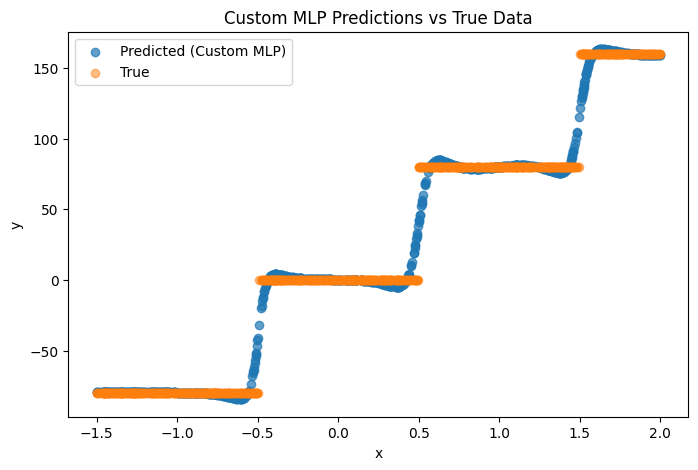

In [22]:
#wykresy z LLM
plt.figure(figsize=(8, 5))
plt.scatter(unnorm["x"], np.array(y_test_pred) * std['y'] + mi['y'], label='Predicted (Custom MLP)', alpha=0.7)
plt.scatter(unnorm["x"], unnorm["y"], label='True', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Custom MLP Predictions vs True Data')
plt.legend()
plt.show()